# Low-Light Image Enhancement using Zero-DCE
## Zero-Reference Deep Curve Estimation with LOL-v2 Dataset

## 1. LOAD DATA

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from tqdm import tqdm
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Define data paths
BASE_PATH = Path('LOL-v2')
TRAIN_PATH = BASE_PATH / 'Real_captured' / 'Train'
TEST_PATH = BASE_PATH / 'Real_captured' / 'Test'

print(f"Base path: {BASE_PATH}")
print(f"Train path exists: {TRAIN_PATH.exists()}")
print(f"Test path exists: {TEST_PATH.exists()}")

Using device: cuda
Base path: LOL-v2
Train path exists: True
Test path exists: True


In [2]:
# Load image file paths
def load_image_pairs(data_path):
    """Load low-light and normal image pairs"""
    low_path = data_path / 'Low'
    normal_path = data_path / 'Normal'
    
    low_images = sorted([f for f in os.listdir(low_path) if f.endswith(('.jpg', '.png'))])
    normal_images = sorted([f for f in os.listdir(normal_path) if f.endswith(('.jpg', '.png'))])
    
    pairs = []
    for low_img, normal_img in zip(low_images, normal_images):
        pairs.append({
            'low': str(low_path / low_img),
            'normal': str(normal_path / normal_img),
            'filename': low_img
        })
    
    return pairs

# Load training and test data
train_pairs = load_image_pairs(TRAIN_PATH)
test_pairs = load_image_pairs(TEST_PATH)

print(f"Training pairs: {len(train_pairs)}")
print(f"Test pairs: {len(test_pairs)}")
print(f"Sample pair: {train_pairs[0]}")

Training pairs: 689
Test pairs: 100
Sample pair: {'low': 'LOL-v2\\Real_captured\\Train\\Low\\low00001.png', 'normal': 'LOL-v2\\Real_captured\\Train\\Normal\\normal00001.png', 'filename': 'low00001.png'}


## 2. EDA (Exploratory Data Analysis)

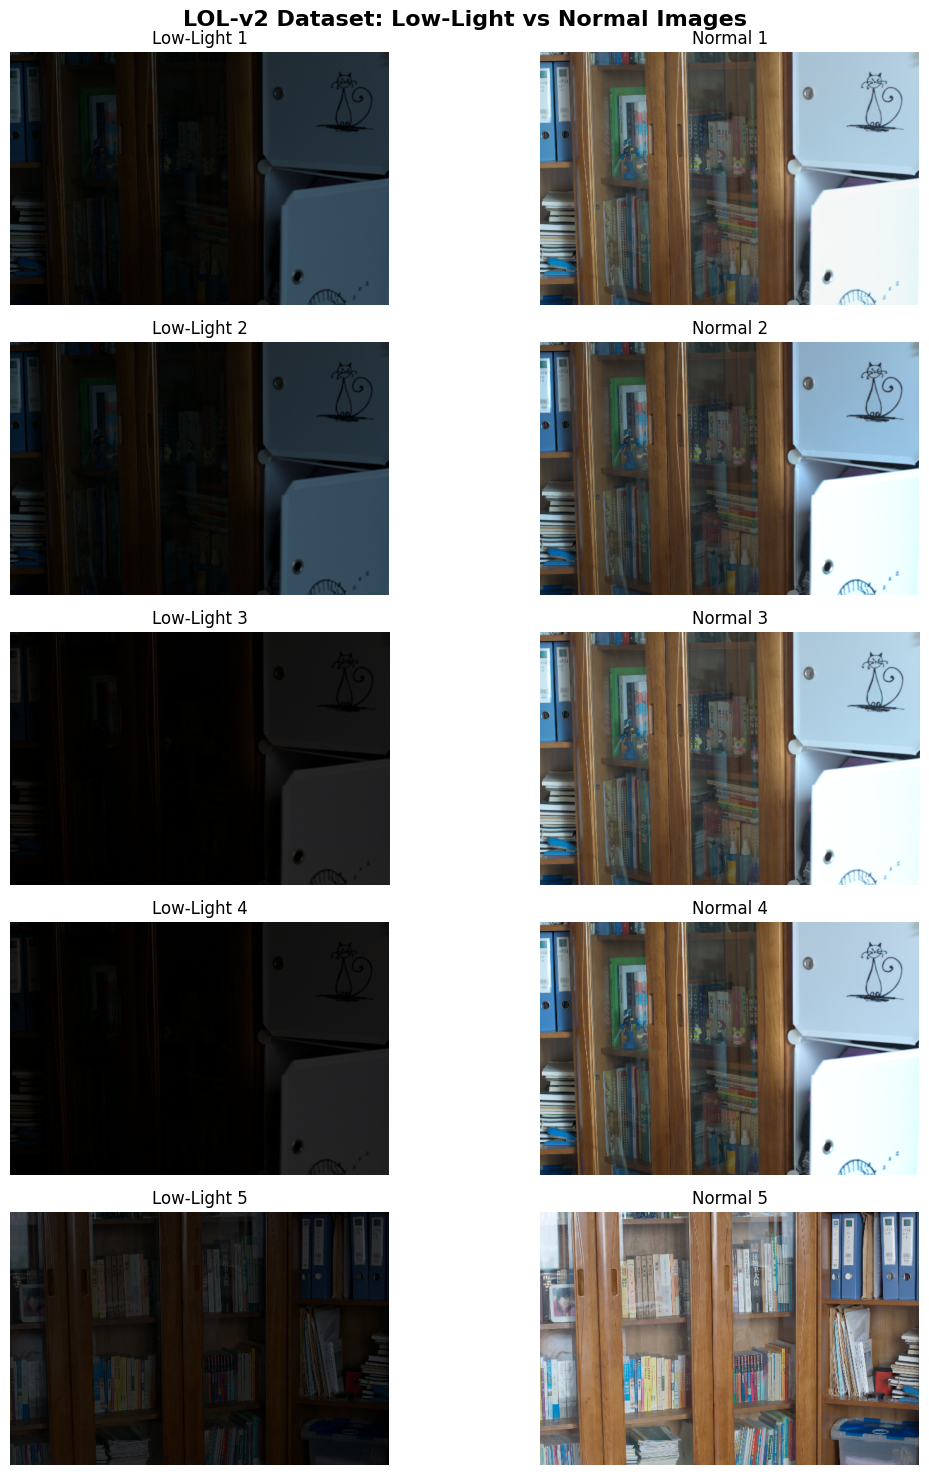

Sample images displayed successfully


In [3]:
# Visualize sample image pairs
fig, axes = plt.subplots(5, 2, figsize=(12, 15))
fig.suptitle('LOL-v2 Dataset: Low-Light vs Normal Images', fontsize=16, fontweight='bold')

for idx in range(5):
    pair = train_pairs[idx]
    
    low_img = cv2.imread(pair['low'])
    low_img = cv2.cvtColor(low_img, cv2.COLOR_BGR2RGB)
    
    normal_img = cv2.imread(pair['normal'])
    normal_img = cv2.cvtColor(normal_img, cv2.COLOR_BGR2RGB)
    
    axes[idx, 0].imshow(low_img)
    axes[idx, 0].set_title(f'Low-Light {idx+1}')
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(normal_img)
    axes[idx, 1].set_title(f'Normal {idx+1}')
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()
print("Sample images displayed successfully")

In [4]:
# Analyze image properties
def analyze_image_stats(img_path):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return {
        'shape': img.shape,
        'mean': img_rgb.mean(axis=(0, 1)),
        'std': img_rgb.std(axis=(0, 1)),
        'min': img_rgb.min(),
        'max': img_rgb.max()
    }

# Analyze low-light vs normal statistics
print("\n=== IMAGE STATISTICS ===")
low_stats = []
normal_stats = []

for pair in train_pairs[:20]:  # Sample first 20
    low_stats.append(analyze_image_stats(pair['low'])['mean'])
    normal_stats.append(analyze_image_stats(pair['normal'])['mean'])

low_mean = np.mean(low_stats, axis=0)
normal_mean = np.mean(normal_stats, axis=0)

print(f"\nLow-Light Images - Mean RGB: {low_mean}")
print(f"Normal Images - Mean RGB: {normal_mean}")
print(f"\nMean pixel intensity difference: {normal_mean - low_mean}")


=== IMAGE STATISTICS ===

Low-Light Images - Mean RGB: [12.55051687 12.61672063 11.45207104]
Normal Images - Mean RGB: [136.24964583 131.41850396 128.5162725 ]

Mean pixel intensity difference: [123.69912896 118.80178333 117.06420146]


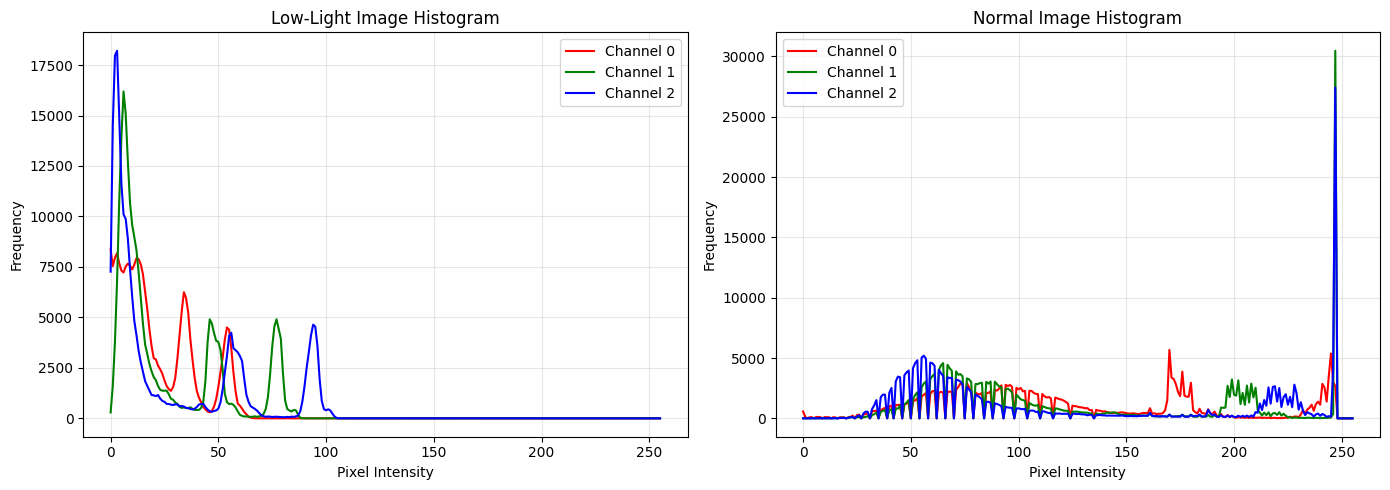

Histogram analysis completed


In [5]:
# Histogram comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sample image
sample_low = cv2.imread(train_pairs[0]['low'])
sample_low = cv2.cvtColor(sample_low, cv2.COLOR_BGR2RGB)
sample_normal = cv2.imread(train_pairs[0]['normal'])
sample_normal = cv2.cvtColor(sample_normal, cv2.COLOR_BGR2RGB)

# Plot histograms
colors = ('r', 'g', 'b')
for channel, color in enumerate(colors):
    hist_low = cv2.calcHist([sample_low], [channel], None, [256], [0, 256])
    axes[0].plot(hist_low, color=color, label=f'Channel {channel}')
    
axes[0].set_title('Low-Light Image Histogram')
axes[0].set_xlabel('Pixel Intensity')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for channel, color in enumerate(colors):
    hist_normal = cv2.calcHist([sample_normal], [channel], None, [256], [0, 256])
    axes[1].plot(hist_normal, color=color, label=f'Channel {channel}')
    
axes[1].set_title('Normal Image Histogram')
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Histogram analysis completed")

In [6]:
# Dataset statistics summary
print("\n" + "="*50)
print("DATASET SUMMARY")
print("="*50)
print(f"Total training pairs: {len(train_pairs)}")
print(f"Total test pairs: {len(test_pairs)}")
print(f"Total samples: {len(train_pairs) + len(test_pairs)}")
print(f"\nImage resolution: {analyze_image_stats(train_pairs[0]['low'])['shape']}")
print(f"Dataset type: Real_captured (photographic)")
print(f"Ground truth available: Yes (normal images)")


DATASET SUMMARY
Total training pairs: 689
Total test pairs: 100
Total samples: 789

Image resolution: (400, 600, 3)
Dataset type: Real_captured (photographic)
Ground truth available: Yes (normal images)
